## 1. Carga y limpieza de datos


### 1.1 Lectura del dataset

In [1]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

data_xlsx = Path('MUESTRAS SELECCIONADAS.xlsx')
data_csv = Path('MUESTRAS SELECCIONADAS.csv')
if data_xlsx.exists():
    df = pd.read_excel(data_xlsx)
elif data_csv.exists():
    # formato con separador ';' y coma decimal ',' 
    try:
        df = pd.read_csv(data_csv, sep=';', decimal=',')
    except Exception:
        df = pd.read_csv(data_csv)
else:
    raise FileNotFoundError('No se encontró MUESTRAS SELECCIONADAS (XLSX/CSV)')

# normalización única de nombres
def clean_col(c):
    c = str(c).strip()
    c = c.replace(' ', '_')
    c = c.replace('/', '_')
    c = re.sub(r'[^0-9A-Za-z_.-]', '', c)
    return c.lower()

df.columns = [clean_col(c) for c in df.columns]
print('Lectura completada. Shape:', df.shape)
print('Columnas normalizadas (muestra primeras 20):')
print(list(df.columns)[:20])

Lectura completada. Shape: (978, 225)
Columnas normalizadas (muestra primeras 20):
['unnamed_0', '950.939', '954.809', '958.674', '962.537', '966.395', '970.25', '974.102', '977.95', '981.794', '985.635', '989.473', '993.307', '997.137', '1000.96', '1004.79', '1008.61', '1012.42', '1016.24', '1020.05']


### 1.2 Revisión de dimensiones

In [2]:
print('Shape:', df.shape)
display(df.head())
print('\nTipos de datos (muestra):')
print(df.dtypes.value_counts())

Shape: (978, 225)


,unnamed_0,950.939,954.809,958.674,962.537,966.395,970.25,974.102,977.95,981.794,...,origin,tss_,ta_g_100ml-1,tpc_peel_mg_100_g1,tpc_juice_mg_100_ml1,weight_g,length_mm,diameter_mm,harvest_date,unnamed_224
0,AH-01-1,0.723489,0.717299,0.712654,0.708373,0.708419,0.706528,0.707738,0.707401,0.710434,...,A,9.3,6.94528,295.192308,47.115385,122.32,78.32,57.07,2020-11-27,NaN
1,AH-02-1,0.829990,0.821159,0.817817,0.812634,0.812876,0.810757,0.811058,0.811725,0.813507,...,A,9.5,6.61248,296.634615,48.269231,155.16,83.80,62.68,2020-11-27,NaN
2,AH-03-1,0.704947,0.698819,0.694230,0.690369,0.691145,0.688394,0.690234,0.691399,0.692460,...,A,9.1,6.21312,304.807692,31.730769,185.50,105.22,62.29,2020-11-27,NaN
3,AH-04-1,0.795015,0.787526,0.781531,0.776222,0.777105,0.773806,0.775343,0.775564,0.778108,...,A,9.4,6.33600,309.615385,46.923077,164.14,90.72,60.26,2020-11-27,NaN
4,AH-05-1,0.390440,0.384035,0.380060,0.376629,0.378434,0.374138,0.375888,0.375337,0.377506,...,A,9.0,6.33088,392.788462,53.846154,243.76,95.20,73.14,2020-11-27,NaN



Tipos de datos (muestra):
float64           219
object              5
datetime64[ns]      1
Name: count, dtype: int64


### 1.3 Identificación de tipos de variables

In [3]:
# clasificación semántica única sobre nombres ya normalizados
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('N columnas numéricas (detectadas):', len(num_cols))

# espectrales: nombres numéricos en el rango NIR típico o nombres semánticos claros
spectral_cols = []
for c in df.columns:
    name = str(c).strip()
    name_num = name.replace(',', '.').replace('_', '')
    try:
        value = float(name_num)
        if 700 <= value <= 2500:
            spectral_cols.append(c)
    except Exception:
        if re.search(r'\b(nm|wl|wavelength|band|spectr|reflectance)\b', name, flags=re.I):
            spectral_cols.append(c)

# variables morfológicas por tokens comunes en el nombre ya normalizado
morpho_tokens = ['weight', 'peso', 'length', 'longitud', 'diameter', 'diametro']
morpho_cols = [c for c in df.columns if any(tok in str(c).lower() for tok in morpho_tokens)]

# variables objetivo por tokens comunes en el nombre ya normalizado
target_tokens = ['tss', 'ta', 'tpc', 'tpc_peel', 'tpc_juice', 'phenolic']
target_cols = [c for c in df.columns if any(tok in str(c).lower() for tok in target_tokens)]

# categóricas definitivas, excluyendo espectrales, morfológicas y objetivo
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in spectral_cols and c not in morpho_cols and c not in target_cols]

print('Espectrales detectadas:', len(spectral_cols))
print('Morpho cols detectadas:', morpho_cols)
print('Categorical cols detectadas:', categorical_cols)
print('Targets detectados:', target_cols)

N columnas numéricas (detectadas): 219
Espectrales detectadas: 212
Morpho cols detectadas: ['weight_g', 'length_mm', 'diameter_mm']
Categorical cols detectadas: ['unnamed_0', 'variety', 'clon_type', 'origin', 'unnamed_224']
Targets detectados: ['tss_', 'ta_g_100ml-1', 'tpc_peel_mg_100_g1', 'tpc_juice_mg_100_ml1']


### 1.4 Detección de valores faltantes

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(20))
display((df.isna().mean().sort_values(ascending=False)*100).head(20))

unnamed_224             977
diameter_mm             161
length_mm               161
weight_g                161
ta_g_100ml-1              6
tpc_juice_mg_100_ml1      3
tpc_peel_mg_100_g1        1
tss_                      1
1479.27                   0
1493.05                   0
1489.61                   0
1486.17                   0
1482.72                   0
1465.46                   0
1475.82                   0
1472.37                   0
1468.91                   0
1499.93                   0
1462                      0
1496.49                   0
dtype: int64

unnamed_224             99.897751
diameter_mm             16.462168
length_mm               16.462168
weight_g                16.462168
ta_g_100ml-1             0.613497
tpc_juice_mg_100_ml1     0.306748
tpc_peel_mg_100_g1       0.102249
tss_                     0.102249
1479.27                  0.000000
1493.05                  0.000000
1489.61                  0.000000
1486.17                  0.000000
1482.72                  0.000000
1465.46                  0.000000
1475.82                  0.000000
1472.37                  0.000000
1468.91                  0.000000
1499.93                  0.000000
1462                     0.000000
1496.49                  0.000000
dtype: float64

### 1.5 Eliminación de columnas inútiles

In [5]:
# eliminar columnas con >50% de valores faltantes y columnas constantes
missing_frac = df.isna().mean()
cols_to_drop = list(missing_frac[missing_frac > 0.5].index)
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
cols_to_drop = list(set(cols_to_drop + const_cols))
print('Columnas a eliminar:', cols_to_drop[:20])
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print('Shape tras eliminar:', df.shape)

Columnas a eliminar: ['unnamed_224']
Shape tras eliminar: (978, 224)


### 1.6 Preparación inicial del dataset

In [6]:
from pathlib import Path
import json

# Guardar dataframe limpio y metadata usando la clasificación única ya definida
Path('results').mkdir(exist_ok=True)
df.to_csv('results/df_clean_initial.csv', index=False)
meta = {
    'spectral_cols': spectral_cols,
    'morpho_cols': morpho_cols,
    'categorical_cols': categorical_cols,
    'target_cols': target_cols,
}
with open('results/df_meta_initial.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print('Preparación inicial completada. Espectrales detectadas:', len(spectral_cols), 'Targets:', target_cols)

Preparación inicial completada. Espectrales detectadas: 212 Targets: ['tss_', 'ta_g_100ml-1', 'tpc_peel_mg_100_g1', 'tpc_juice_mg_100_ml1']


## 2. Análisis Exploratorio de Datos (EDA)

In [7]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

DF_PATH = 'results/df_clean_initial.csv'
META_PATH = 'results/df_meta_initial.json'

assert os.path.exists(DF_PATH), f'{DF_PATH} not found'
assert os.path.exists(META_PATH), f'{META_PATH} not found'

df = pd.read_csv(DF_PATH)
with open(META_PATH, 'r', encoding='utf-8') as f:
    meta = json.load(f)

spectral_cols = meta.get('spectral_cols', [])
morpho_cols = meta.get('morpho_cols', [])
target_cols = meta.get('target_cols', [])
categorical_cols = meta.get('categorical_cols', [])

## carga del dataset limpio y las listas de columnas guardadas en la celda 7
for c in spectral_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Shape del dataset:', df.shape)
print('Variables objetivo:', target_cols)
print('Variables morfológicas:', morpho_cols)
print('Variables categóricas:', categorical_cols)
print('Bandas espectrales detectadas:', len(spectral_cols))

# variable de grupo para los gráficos exploratorios
group_col = 'variety' if 'variety' in df.columns else ('origin' if 'origin' in df.columns else None)
print('Grupo de color seleccionado:', group_col)
display(df.head())
display(df.describe(include='all').T.head(15))

Shape del dataset: (978, 224)
Variables objetivo: ['tss_', 'ta_g_100ml-1', 'tpc_peel_mg_100_g1', 'tpc_juice_mg_100_ml1']
Variables morfológicas: ['weight_g', 'length_mm', 'diameter_mm']
Variables categóricas: ['unnamed_0', 'variety', 'clon_type', 'origin', 'unnamed_224']
Bandas espectrales detectadas: 212
Grupo de color seleccionado: variety


,unnamed_0,950.939,954.809,958.674,962.537,966.395,970.25,974.102,977.95,981.794,...,clon_type,origin,tss_,ta_g_100ml-1,tpc_peel_mg_100_g1,tpc_juice_mg_100_ml1,weight_g,length_mm,diameter_mm,harvest_date
0,AH-01-1,0.723489,0.717299,0.712654,0.708373,0.708419,0.706528,0.707738,0.707401,0.710434,...,E-SL,A,9.3,6.94528,295.192308,47.115385,122.32,78.32,57.07,2020-11-27
1,AH-02-1,0.829990,0.821159,0.817817,0.812634,0.812876,0.810757,0.811058,0.811725,0.813507,...,E-SL,A,9.5,6.61248,296.634615,48.269231,155.16,83.80,62.68,2020-11-27
2,AH-03-1,0.704947,0.698819,0.694230,0.690369,0.691145,0.688394,0.690234,0.691399,0.692460,...,E-SL,A,9.1,6.21312,304.807692,31.730769,185.50,105.22,62.29,2020-11-27
3,AH-04-1,0.795015,0.787526,0.781531,0.776222,0.777105,0.773806,0.775343,0.775564,0.778108,...,E-SL,A,9.4,6.33600,309.615385,46.923077,164.14,90.72,60.26,2020-11-27
4,AH-05-1,0.390440,0.384035,0.380060,0.376629,0.378434,0.374138,0.375888,0.375337,0.377506,...,E-SL,A,9.0,6.33088,392.788462,53.846154,243.76,95.20,73.14,2020-11-27


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
unnamed_0,978,978,AH-01-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
950.939,978.0,NaN,NaN,NaN,0.50441,0.125043,0.145794,0.408942,0.494836,0.593143,0.913553
954.809,978.0,NaN,NaN,NaN,0.49945,0.124131,0.144651,0.405034,0.489921,0.586265,0.904344
958.674,978.0,NaN,NaN,NaN,0.49504,0.123431,0.145598,0.40088,0.485593,0.581137,0.898293
962.537,978.0,NaN,NaN,NaN,0.488635,0.122919,0.140324,0.395683,0.480367,0.574319,0.882374
966.395,978.0,NaN,NaN,NaN,0.491938,0.123225,0.142417,0.39865,0.482987,0.578042,0.894387
970.25,978.0,NaN,NaN,NaN,0.487699,0.122664,0.13936,0.395394,0.479877,0.57263,0.879965
974.102,978.0,NaN,NaN,NaN,0.489744,0.12284,0.140689,0.397663,0.482151,0.574558,0.885441
977.95,978.0,NaN,NaN,NaN,0.489018,0.123049,0.140261,0.395569,0.48212,0.574236,0.881529
981.794,978.0,NaN,NaN,NaN,0.490682,0.123189,0.140895,0.396844,0.483907,0.576086,0.883571


### 2.1 Distribuciones y correlaciones

,faltantes
weight_g,161
length_mm,161
diameter_mm,161
ta_g_100ml-1,6
tpc_juice_mg_100_ml1,3
tss_,1
tpc_peel_mg_100_g1,1


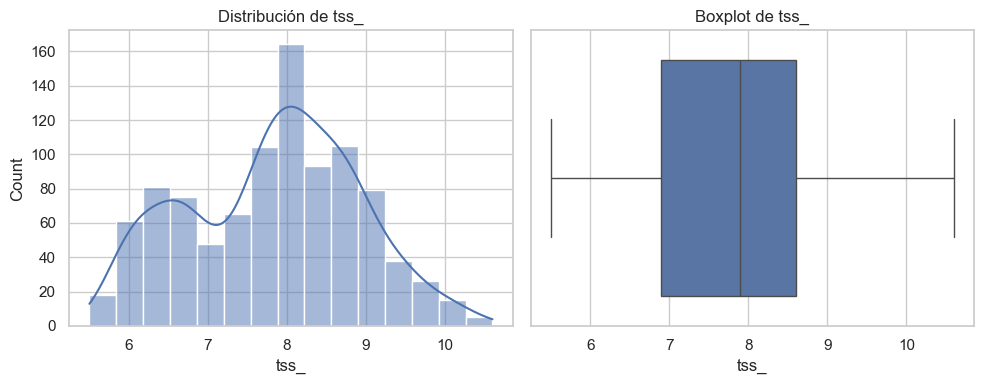

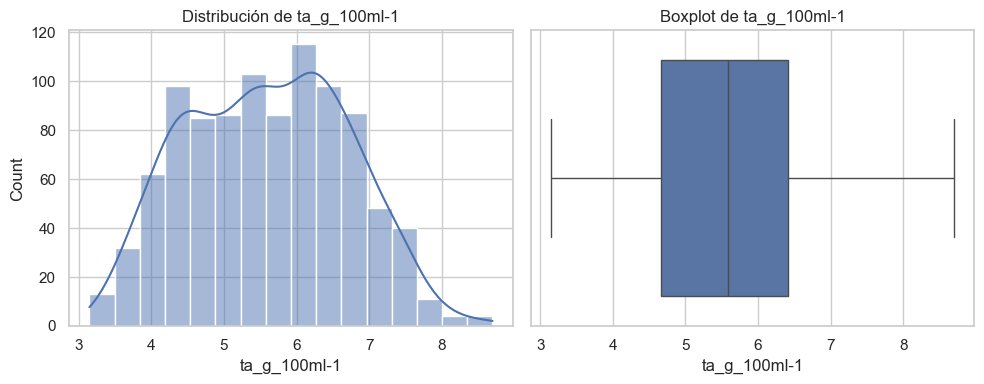

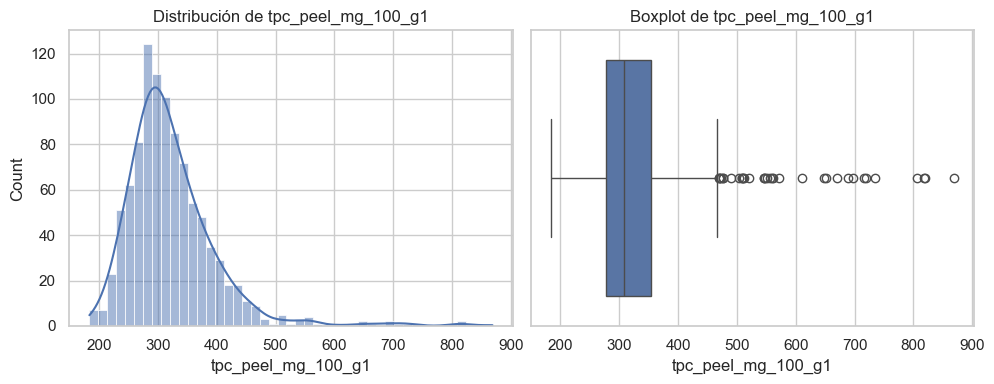

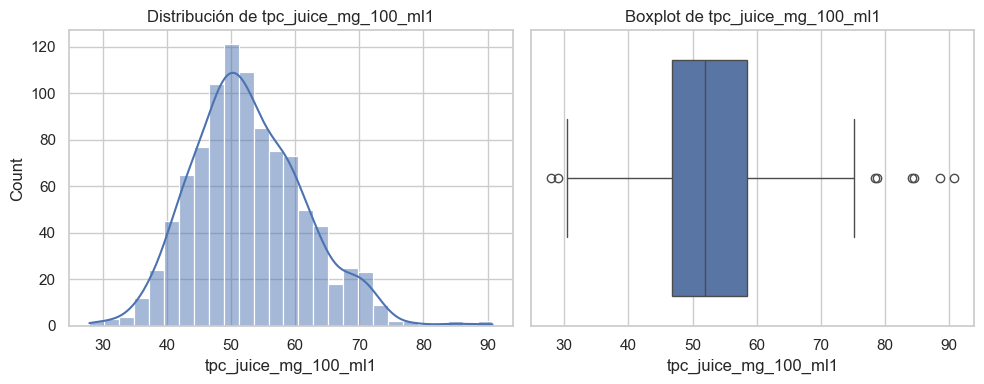

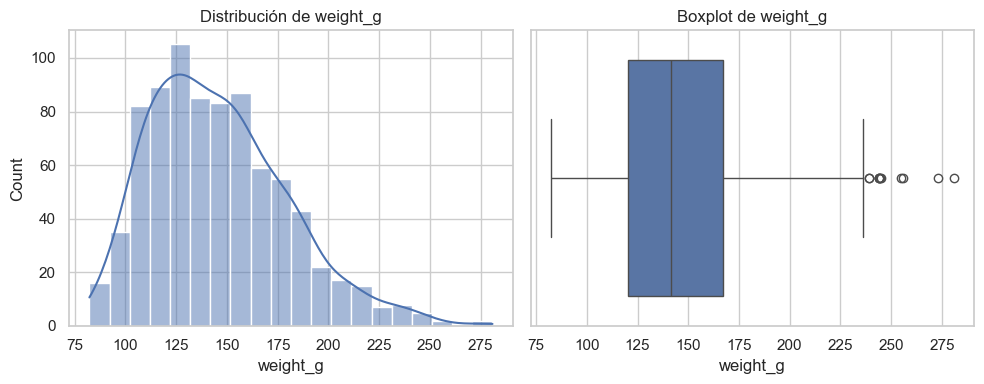

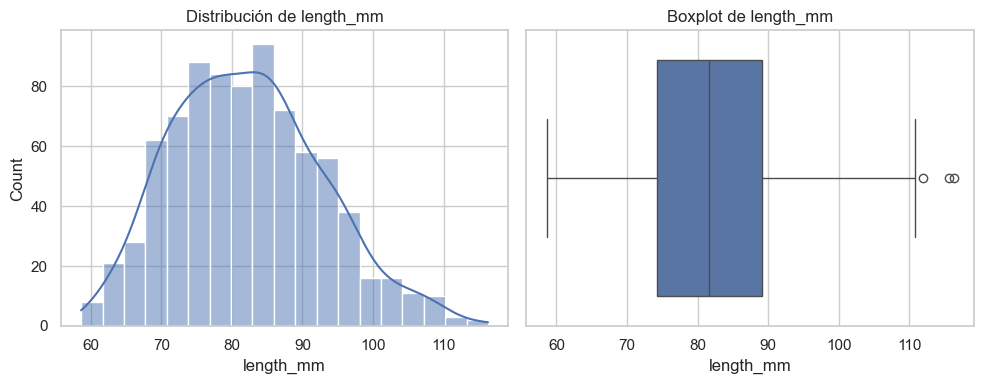

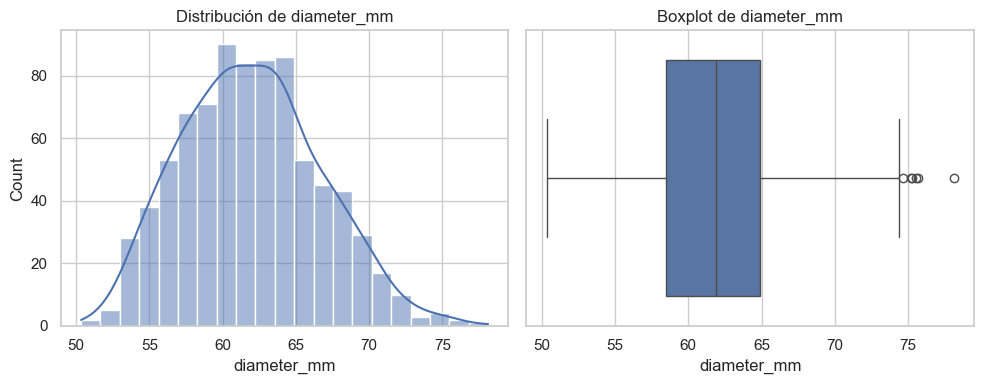

In [8]:
# Distribuciones de variables objetivo y morfológicas
basic_cols = list(dict.fromkeys(target_cols + morpho_cols))
missing = df[basic_cols].isna().sum().sort_values(ascending=False)
display(missing.to_frame('faltantes'))

for col in basic_cols:
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    if s.empty:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(s, ax=axes[0], kde=True)
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    sns.boxplot(x=s, ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

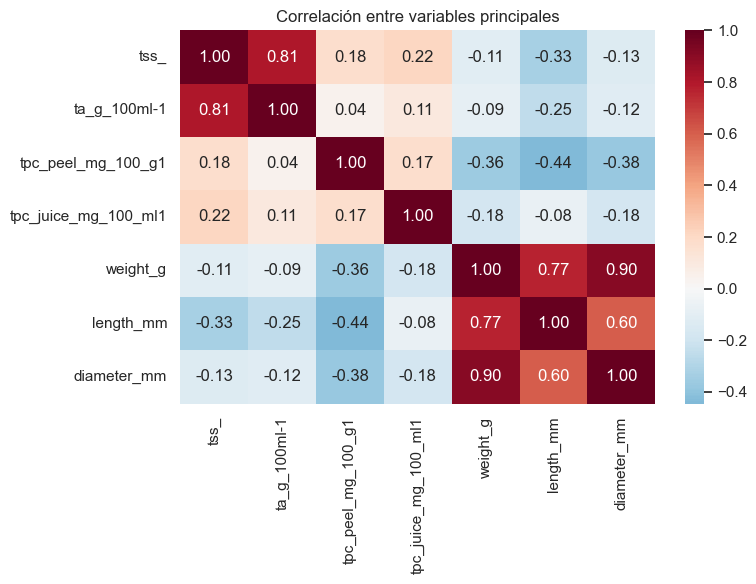

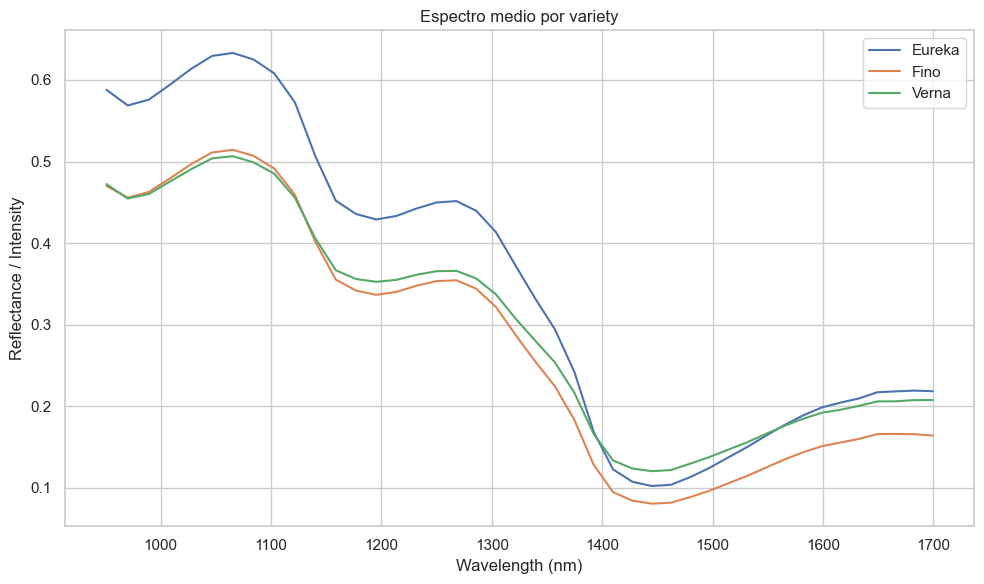

In [9]:
# Correlación entre variables principales y espectro medio por variedad
if len(basic_cols) >= 2:
    corr_df = df[basic_cols].apply(pd.to_numeric, errors='coerce')
    corr = corr_df.corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
    ax.set_title('Correlación entre variables principales')
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print('No hay suficientes variables para calcular correlaciones.')

# Espectro NIR medio por variedad
if group_col is not None and len(spectral_cols) > 0:
    groups = df[group_col].dropna().unique()
    groups = [g for g in groups if df[df[group_col] == g].shape[0] >= 3][:3]
    spec_plot = spectral_cols[::max(1, len(spectral_cols) // 40)] if len(spectral_cols) > 40 else spectral_cols
    wavelengths = [float(str(c).replace('_', '').replace(',', '.')) for c in spec_plot]
    fig, ax = plt.subplots(figsize=(10, 6))
    for g in groups:
        sub = df[df[group_col] == g][spec_plot].apply(pd.to_numeric, errors='coerce')
        mean = sub.mean(axis=0)
        ax.plot(wavelengths, mean, label=str(g))
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Reflectance / Intensity')
    ax.set_title(f'Espectro medio por {group_col}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close(fig)
else:
    print('No se pudo hacer la comparación de espectros por grupo.')

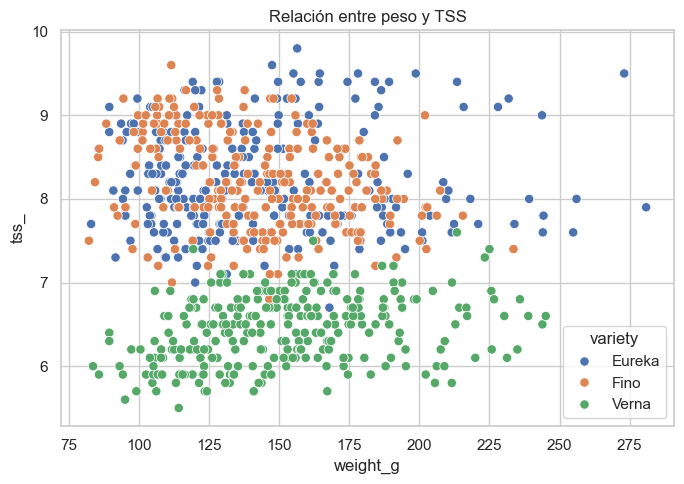

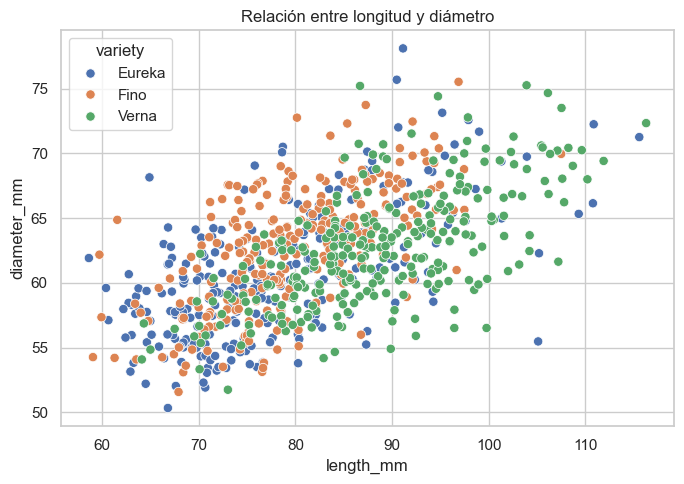

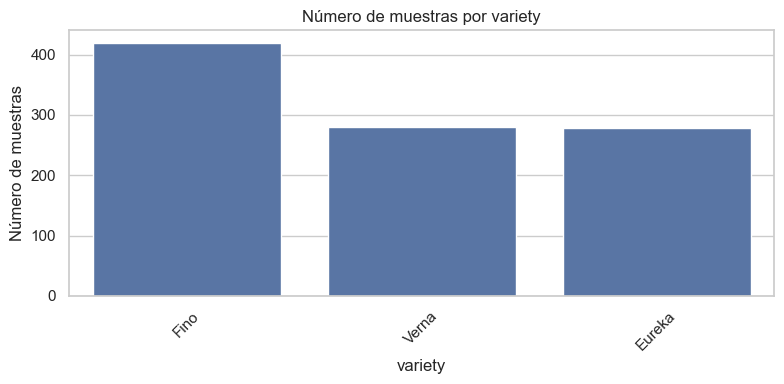

In [10]:
# Relación entre variables morfológicas y objetivo; distribución por variedad
if 'tss_' in df.columns and 'weight_g' in df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=df, x='weight_g', y='tss_', hue=group_col if group_col in df.columns else None, ax=ax, s=45)
    ax.set_title('Relación entre peso y TSS')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

if 'length_mm' in df.columns and 'diameter_mm' in df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=df, x='length_mm', y='diameter_mm', hue=group_col if group_col in df.columns else None, ax=ax, s=45)
    ax.set_title('Relación entre longitud y diámetro')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

if group_col in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    order = df[group_col].value_counts().index
    sns.countplot(data=df, x=group_col, order=order, ax=ax)
    ax.set_title(f'Número de muestras por {group_col}')
    ax.set_xlabel(group_col)
    ax.set_ylabel('Número de muestras')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


### 2.2 Calidad de datos y comparación por variedad

In [11]:
# Duplicados, faltantes y estadísticos descriptivos por variedad
print('Filas duplicadas:', df.duplicated().sum())
print('Porcentaje de filas duplicadas: {:.2f}%'.format(df.duplicated().mean() * 100))

print('\nValores faltantes en variables principales:')
display(df[basic_cols].isna().sum().to_frame('faltantes').sort_values('faltantes', ascending=False))

print('\nResumen rápido de variables principales:')
display(df[basic_cols].describe().T)

if 'variety' in df.columns:
    print('\nMedia de variables principales por variedad:')
    summary_cols = [c for c in basic_cols if c in df.columns]
    display(df.groupby('variety')[summary_cols].mean(numeric_only=True).round(2))
    print('\nNúmero de muestras por variedad:')
    display(df['variety'].value_counts().to_frame('muestras'))

Filas duplicadas: 0
Porcentaje de filas duplicadas: 0.00%

Valores faltantes en variables principales:


,faltantes
weight_g,161
length_mm,161
diameter_mm,161
ta_g_100ml-1,6
tpc_juice_mg_100_ml1,3
tss_,1
tpc_peel_mg_100_g1,1



Resumen rápido de variables principales:


,count,mean,std,min,25%,50%,75%,max
tss_,977.0,7.824258,1.083509,5.500000,6.900000,7.900000,8.600000,10.600000
ta_g_100ml-1,972.0,5.594738,1.104841,3.146240,4.664320,5.589760,6.411520,8.696320
tpc_peel_mg_100_g1,977.0,322.872021,78.043632,183.573718,277.403846,308.653846,353.205128,868.717949
tpc_juice_mg_100_ml1,975.0,52.721913,8.756742,27.884615,46.730769,51.923077,58.461538,90.769231
weight_g,817.0,145.907099,34.001387,82.240000,120.140000,141.260000,167.150000,280.880000
length_mm,817.0,82.221200,10.606288,58.620000,74.280000,81.690000,89.130000,116.310000
diameter_mm,817.0,61.954982,4.723264,50.340000,58.470000,61.870000,64.910000,78.110000



Media de variables principales por variedad:


,tss_,ta_g_100ml-1,tpc_peel_mg_100_g1,tpc_juice_mg_100_ml1,weight_g,length_mm,diameter_mm
variety,,,,,,,
Eureka,8.22,5.86,378.32,50.37,142.37,78.14,60.57
Fino,8.49,6.30,303.35,53.38,143.04,79.74,62.66
Verna,6.44,4.30,296.75,54.09,152.07,88.57,62.69



Número de muestras por variedad:


,muestras
variety,
Fino,419
Verna,280
Eureka,279


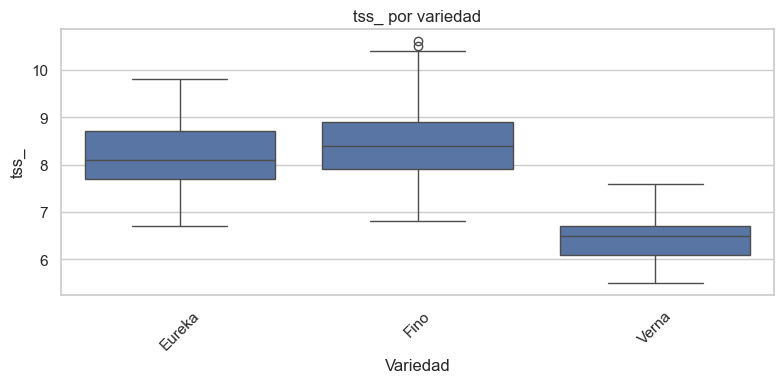

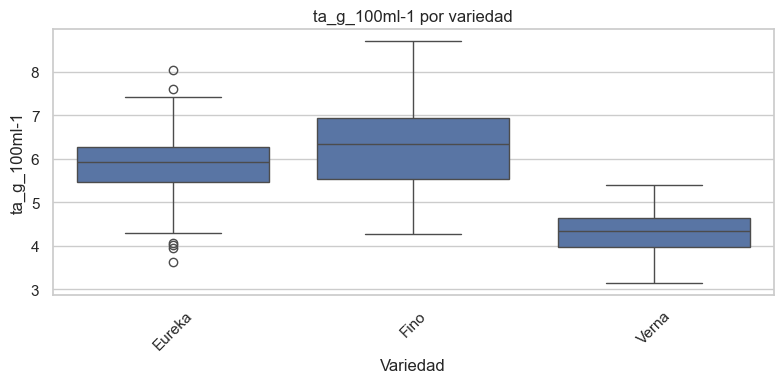

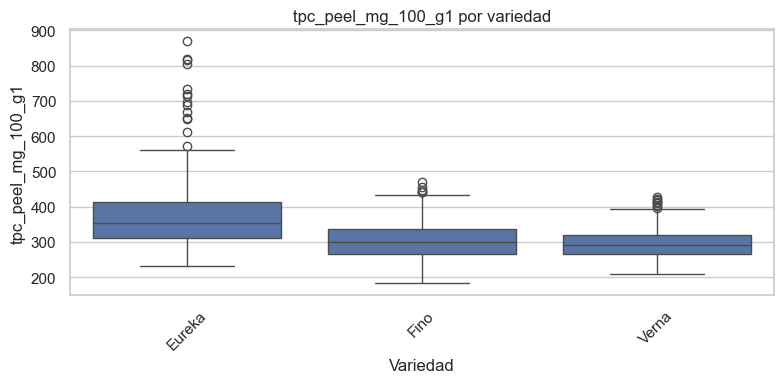

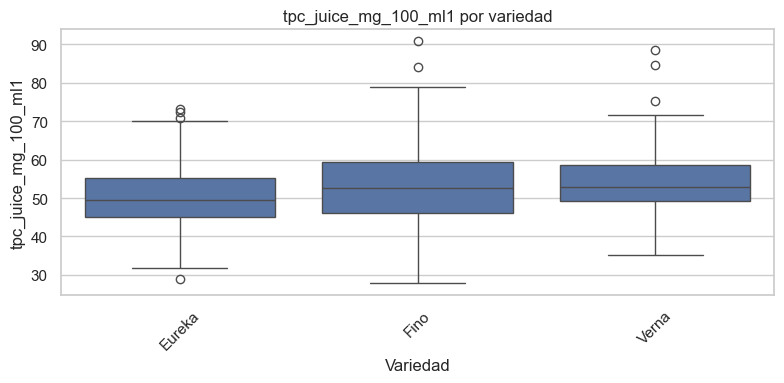

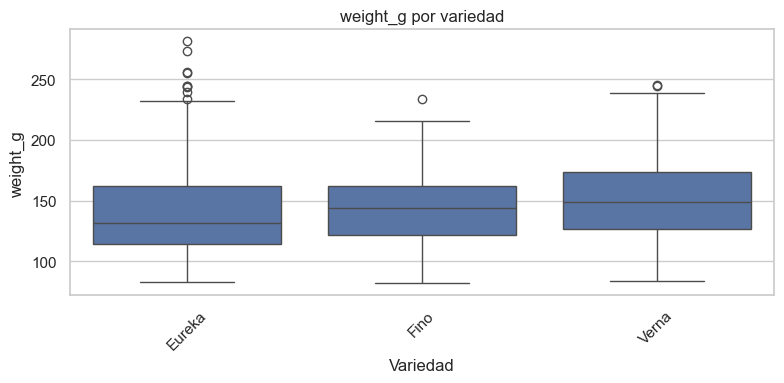

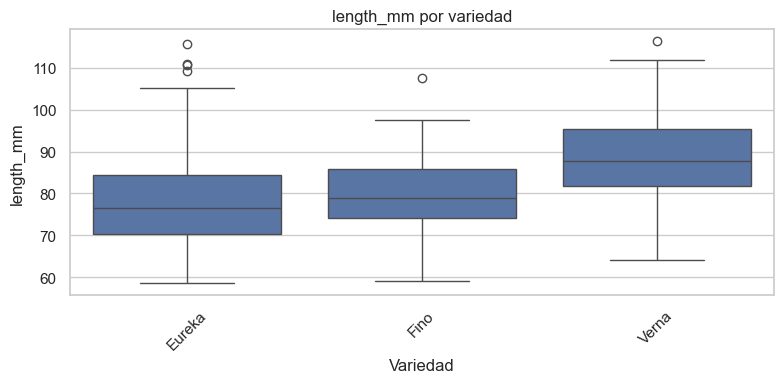

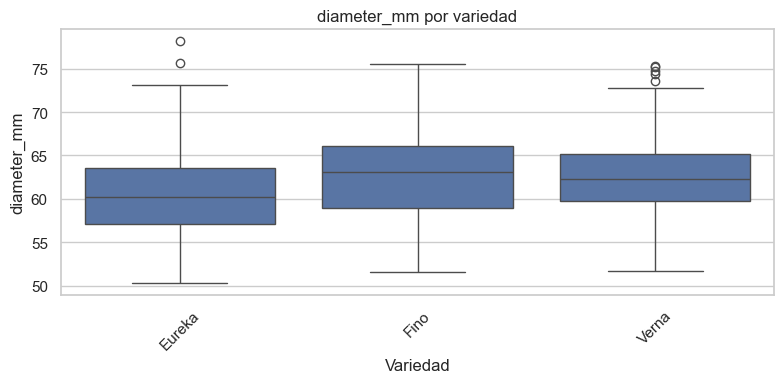

In [12]:
# Boxplots de todas las variables principales por variedad
if 'variety' in df.columns:
    compare_cols = [c for c in ['tss_', 'ta_g_100ml-1', 'tpc_peel_mg_100_g1', 'tpc_juice_mg_100_ml1', 'weight_g', 'length_mm', 'diameter_mm'] if c in df.columns]
    for col in compare_cols:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.boxplot(data=df, x='variety', y=col, ax=ax)
        ax.set_title(f'{col} por variedad')
        ax.set_xlabel('Variedad')
        ax.set_ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        plt.close(fig)
else:
    print('No existe la columna variety en el dataset.')

## 3. Detección de anomalías

In [13]:
# Imports para detección de anomalías
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2, mannwhitneyu

### 3.1 Anomalías morfológicas y espectrales (Mahalanobis + PCA)


Resumen de anomalías detectadas:
Outliers morfológicos: 48
Outliers espectrales: 90
Outliers combinados: 134


outlier_type,both,morphology,normal,spectral,All
variety,,,,,
Eureka,3,21,200,55,279
Fino,1,4,399,15,419
Verna,0,19,245,16,280
All,4,44,844,86,978


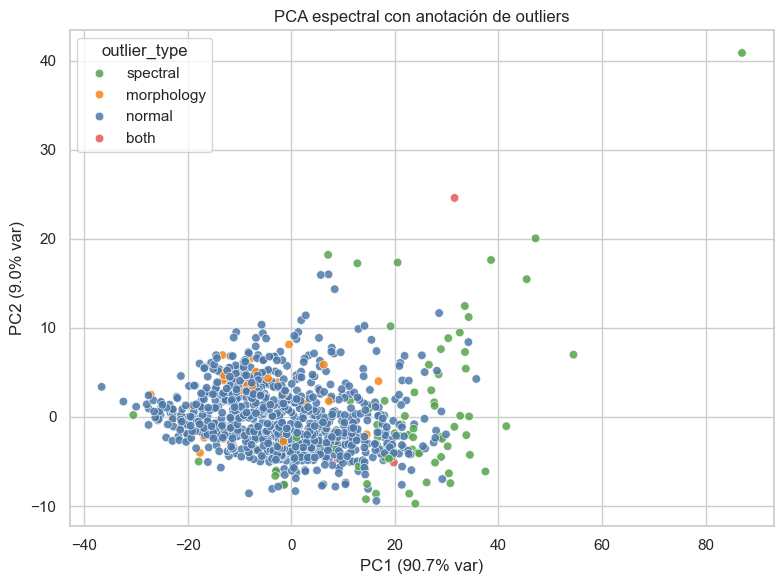

,outlier_group,target,n_outliers,n_non_outliers,mean_outliers,mean_non_outliers,median_outliers,median_non_outliers,cohens_d,p_value,p_bonferroni
11,combined,tpc_juice_mg_100_ml1,134,841,50.2425,53.1170,49.4231,52.3077,-0.3410,0.0003,0.0039
9,combined,ta_g_100ml-1,134,838,5.3491,5.6340,5.4861,5.6410,-0.2810,0.0071,0.0849
8,combined,tss_,134,843,7.7403,7.8376,7.8000,8.0000,-0.0927,0.2094,1.0000
10,combined,tpc_peel_mg_100_g1,134,843,324.2860,322.6473,304.2949,309.1346,0.0213,0.9650,1.0000
1,morphological,ta_g_100ml-1,48,924,5.1584,5.6174,5.3491,5.6128,-0.4515,0.0057,0.0679
2,morphological,tpc_peel_mg_100_g1,48,929,302.9347,323.9022,283.8942,310.4487,-0.2923,0.0121,0.1456
3,morphological,tpc_juice_mg_100_ml1,48,927,49.7396,52.8763,49.3269,52.1154,-0.3722,0.0187,0.2243
0,morphological,tss_,48,929,7.5562,7.8381,7.6500,8.0000,-0.2592,0.0709,0.8514
7,spectral,tpc_juice_mg_100_ml1,90,885,50.5491,52.9429,49.5192,52.1154,-0.2822,0.0075,0.0898
6,spectral,tpc_peel_mg_100_g1,90,887,337.1474,321.4236,322.3558,307.6442,0.2011,0.0381,0.4572


Resultado global: hay diferencias significativas en al menos una combinación outlier-target tras corrección conservadora.


,outlier_group,target,p_bonferroni,cohens_d
11,combined,tpc_juice_mg_100_ml1,0.0039,-0.341


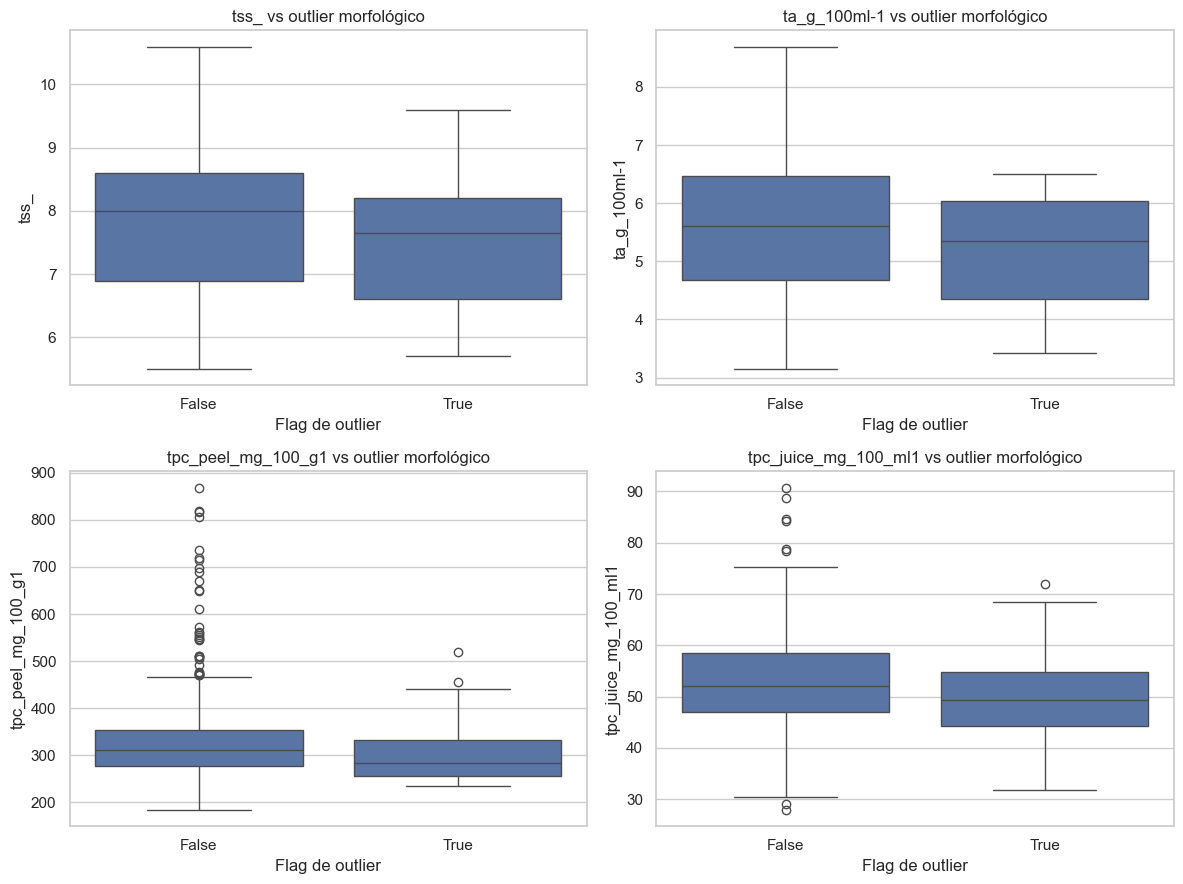

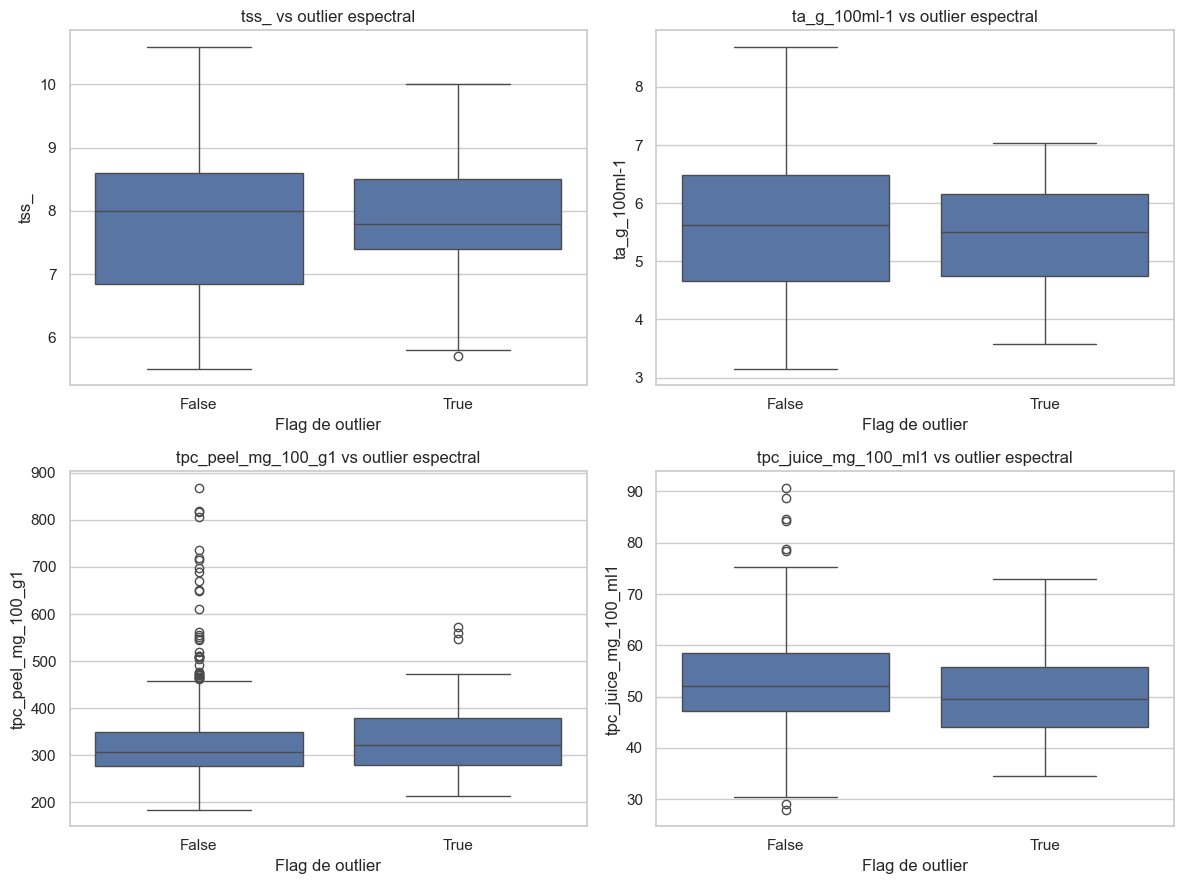

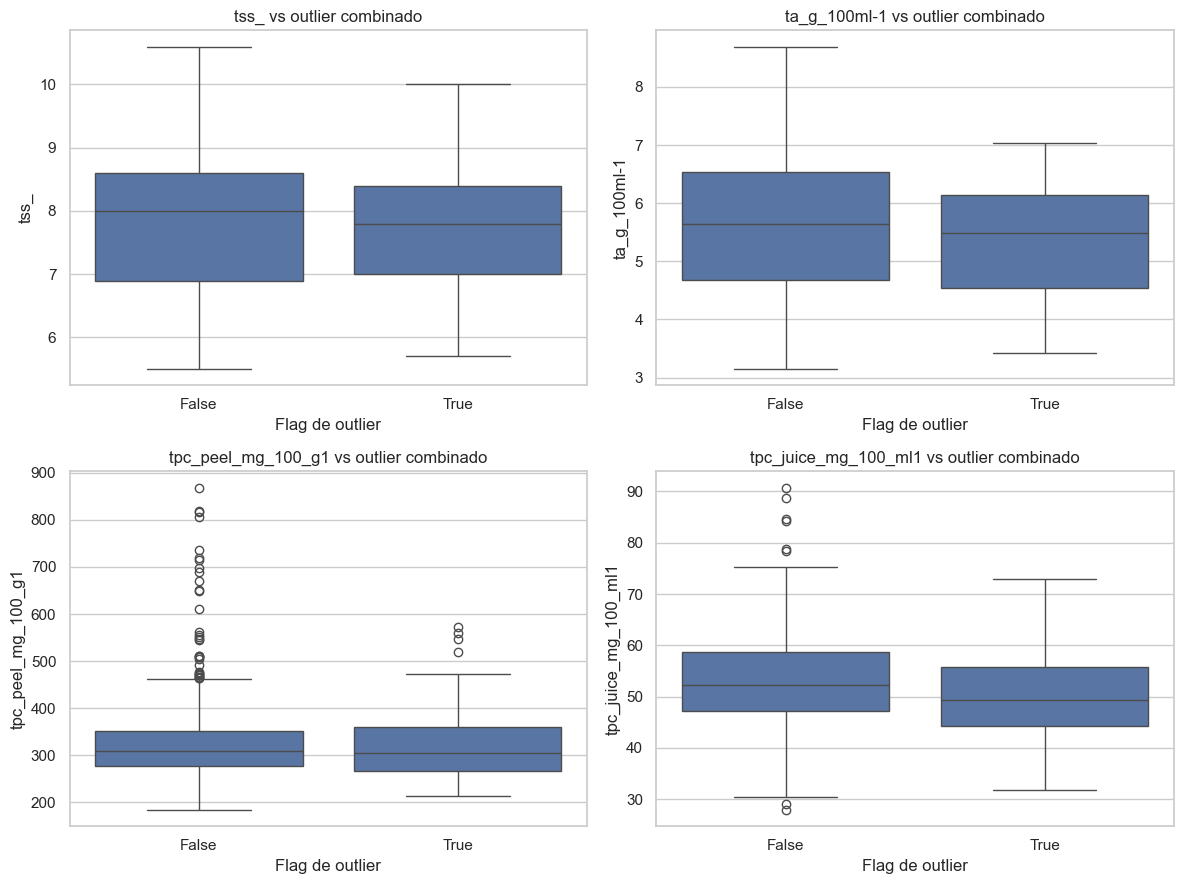

In [14]:

outlier_targets = [c for c in ['tss_', 'ta_g_100ml-1', 'tpc_peel_mg_100_g1', 'tpc_juice_mg_100_ml1'] if c in df.columns]
morpho_present = [c for c in morpho_cols if c in df.columns]
spec_present = [c for c in spectral_cols if c in df.columns]

if len(outlier_targets) != 4:
    print(f'Advertencia: se han encontrado {len(outlier_targets)} variables objetivo de 4 esperadas.')
if len(morpho_present) < 2:
    raise ValueError('No hay suficientes variables morfológicas para estimar outliers morfológicos.')
if len(spec_present) < 5:
    raise ValueError('No hay suficientes bandas espectrales para estimar outliers espectrales.')

analysis_df = df[outlier_targets + morpho_present + spec_present + ([group_col] if group_col in df.columns else [])].copy()

# 1 Outliers morfológicos
morpho_num = analysis_df[morpho_present].apply(pd.to_numeric, errors='coerce')
morpho_num = morpho_num.fillna(morpho_num.median(numeric_only=True))

morpho_scaler = StandardScaler()
morpho_scaled = morpho_scaler.fit_transform(morpho_num)
morpho_cov = np.cov(morpho_scaled, rowvar=False)
morpho_cov_inv = np.linalg.pinv(morpho_cov)
morpho_centered = morpho_scaled - morpho_scaled.mean(axis=0)
morpho_md2 = np.einsum('ij,jk,ik->i', morpho_centered, morpho_cov_inv, morpho_centered)
morpho_threshold = chi2.ppf(0.975, df=morpho_scaled.shape[1])

morpho_mad = morpho_num.apply(lambda s: np.median(np.abs(s - np.median(s))))
robust_z = morpho_num.apply(
    lambda s: 0.6745 * (s - np.median(s)) / np.where(np.median(np.abs(s - np.median(s))) == 0, np.nan, np.median(np.abs(s - np.median(s))))
)
robust_flag = robust_z.abs().gt(3.5).any(axis=1).fillna(False)

analysis_df['morpho_md2'] = morpho_md2
analysis_df['morpho_outlier'] = (analysis_df['morpho_md2'] > morpho_threshold) | robust_flag

# 2 Outliers espectrales
spec_num = analysis_df[spec_present].apply(pd.to_numeric, errors='coerce')
spec_num = spec_num.fillna(spec_num.median(numeric_only=True))

spec_scaler = StandardScaler()
spec_scaled = spec_scaler.fit_transform(spec_num)
max_components = min(12, spec_scaled.shape[0] - 1, spec_scaled.shape[1])
if max_components < 2:
    raise ValueError('No hay suficientes observaciones o variables para aplicar PCA de forma estable.')

pca = PCA(n_components=max_components, random_state=42)
spec_scores = pca.fit_transform(spec_scaled)
spec_reconstruction = pca.inverse_transform(spec_scores)
spec_recon_error = np.mean((spec_scaled - spec_reconstruction) ** 2, axis=1)
spec_t2 = np.sum((spec_scores ** 2) / pca.explained_variance_, axis=1)
spec_t2_threshold = chi2.ppf(0.975, df=max_components)
spec_recon_threshold = np.quantile(spec_recon_error, 0.975)

analysis_df['spec_t2'] = spec_t2
analysis_df['spec_recon_error'] = spec_recon_error
analysis_df['spectral_outlier'] = (analysis_df['spec_t2'] > spec_t2_threshold) | (analysis_df['spec_recon_error'] > spec_recon_threshold)
analysis_df['any_outlier'] = analysis_df['morpho_outlier'] | analysis_df['spectral_outlier']
analysis_df['outlier_type'] = np.select(
    [analysis_df['morpho_outlier'] & analysis_df['spectral_outlier'], analysis_df['morpho_outlier'], analysis_df['spectral_outlier']],
    ['both', 'morphology', 'spectral'],
    default='normal'
)

print('Resumen de anomalías detectadas:')
print('Outliers morfológicos:', int(analysis_df['morpho_outlier'].sum()))
print('Outliers espectrales:', int(analysis_df['spectral_outlier'].sum()))
print('Outliers combinados:', int(analysis_df['any_outlier'].sum()))

if group_col in analysis_df.columns:
    display(pd.crosstab(analysis_df[group_col], analysis_df['outlier_type'], margins=True))

# 3 Visualización PCA + outliers
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=spec_scores[:, 0],
    y=spec_scores[:, 1],
    hue=analysis_df['outlier_type'],
    palette={'normal': '#4C78A8', 'morphology': '#F58518', 'spectral': '#54A24B', 'both': '#E45756'},
    s=38,
    alpha=0.85,
    ax=ax,
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% var)')
ax.set_title('PCA espectral con anotación de outliers')
plt.tight_layout()
plt.show()
plt.close(fig)

# Cruce de outliers con variables químicas (Mann-Whitney + Cohen's d)
def cohens_d(sample_a, sample_b):
    sample_a = pd.to_numeric(pd.Series(sample_a), errors='coerce').dropna()
    sample_b = pd.to_numeric(pd.Series(sample_b), errors='coerce').dropna()
    if len(sample_a) < 2 or len(sample_b) < 2:
        return np.nan
    pooled_std = np.sqrt(((sample_a.std(ddof=1) ** 2) + (sample_b.std(ddof=1) ** 2)) / 2)
    if pooled_std == 0 or np.isnan(pooled_std):
        return np.nan
    return (sample_a.mean() - sample_b.mean()) / pooled_std

comparison_rows = []
for flag_col, flag_label in [('morpho_outlier', 'morphological'), ('spectral_outlier', 'spectral'), ('any_outlier', 'combined')]:
    for target in outlier_targets:
        target_frame = analysis_df[[flag_col, target]].dropna().copy()
        group_out = pd.to_numeric(target_frame.loc[target_frame[flag_col], target], errors='coerce').dropna()
        group_in = pd.to_numeric(target_frame.loc[~target_frame[flag_col], target], errors='coerce').dropna()
        if len(group_out) < 2 or len(group_in) < 2:
            continue

        stat, p_value = mannwhitneyu(group_out, group_in, alternative='two-sided')
        comparison_rows.append({
            'outlier_group': flag_label,
            'target': target,
            'n_outliers': len(group_out),
            'n_non_outliers': len(group_in),
            'mean_outliers': group_out.mean(),
            'mean_non_outliers': group_in.mean(),
            'median_outliers': group_out.median(),
            'median_non_outliers': group_in.median(),
            'mannwhitney_u': stat,
            'p_value': p_value,
            'cohens_d': cohens_d(group_out, group_in),
        })

comparison_df = pd.DataFrame(comparison_rows)
if not comparison_df.empty:
    comparison_df['p_bonferroni'] = np.minimum(comparison_df['p_value'] * len(comparison_df), 1.0)
    display(
        comparison_df.sort_values(['outlier_group', 'p_bonferroni'])[
            ['outlier_group', 'target', 'n_outliers', 'n_non_outliers', 'mean_outliers', 'mean_non_outliers', 'median_outliers', 'median_non_outliers', 'cohens_d', 'p_value', 'p_bonferroni']
        ].round(4)
    )

    sig = comparison_df.loc[comparison_df['p_bonferroni'] < 0.05]
    if len(sig) == 0:
        print('Resultado global: no aparece evidencia estadística fuerte de diferencias químicas entre outliers y no outliers tras corrección conservadora.')
    else:
        print('Resultado global: hay diferencias significativas en al menos una combinación outlier-target tras corrección conservadora.')
        display(sig[['outlier_group', 'target', 'p_bonferroni', 'cohens_d']].round(4))

    for flag_col, flag_label in [('morpho_outlier', 'Outlier morfológico'), ('spectral_outlier', 'Outlier espectral'), ('any_outlier', 'Outlier combinado')]:
        fig, axes = plt.subplots(2, 2, figsize=(12, 9))
        axes = axes.ravel()
        for ax, target in zip(axes, outlier_targets):
            sns.boxplot(data=analysis_df, x=flag_col, y=target, ax=ax)
            ax.set_title(f'{target} vs {flag_label.lower()}')
            ax.set_xlabel('Flag de outlier')
            ax.set_ylabel(target)
        plt.tight_layout()
        plt.show()
        plt.close(fig)
else:
    print('No se han podido construir las comparaciones outlier-target.')

### 3.2 Comparativa univariante: Percentil, 3-Sigma e IQR


In [15]:
import numpy as np
import pandas as pd


# 1. Identificamos todas las columnas numéricas automáticamente (morfológicas, químicas y espectrales)
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()

columnas_numericas = [c for c in columnas_numericas if c not in target_cols]

resultados_totales = []

for var in columnas_numericas:
    # Limpiamos nulos de la columna actual para calcular correctamente
    serie = pd.to_numeric(df[var], errors='coerce').dropna()
    if serie.empty:
        continue
        
    total_muestras = len(serie)
    
    # --- REGLA 1: Percentiles (1% - 99%) ---
    p1 = np.percentile(serie, 1)
    p99 = np.percentile(serie, 99)
    outliers_pct = serie[(serie < p1) | (serie > p99)].index
    
    # --- REGLA 2: Tres Sigmas (Media +- 3 * Desviación Estándar) ---
    media = serie.mean()
    desviacion = serie.std()
    lim_inf_sigma = media - 3 * desviacion
    lim_sup_sigma = media + 3 * desviacion
    outliers_sigma = serie[(serie < lim_inf_sigma) | (serie > lim_sup_sigma)].index
    
    # --- REGLA 3: Rango Intercuartílico / Tukey (IQR) ---
    q1 = np.percentile(serie, 25)
    q3 = np.percentile(serie, 75)
    iqr = q3 - q1
    lim_inf_tukey = q1 - 1.5 * iqr
    lim_sup_tukey = q3 + 1.5 * iqr
    outliers_tukey = serie[(serie < lim_inf_tukey) | (serie > lim_sup_tukey)].index
    
    # Guardamos el recuento de esta variable
    resultados_totales.append({
        'Variable / Banda': var,
        'Muestras Válidas': total_muestras,
        'Outliers Percentil (1%-99%)': len(outliers_pct),
        'Outliers 3-Sigma (Extremos)': len(outliers_sigma),
        'Outliers Tukey (1.5*IQR)': len(outliers_tukey)
    })

# 2. Convertimos el informe a DataFrame
df_anomalias_completo = pd.DataFrame(resultados_totales)

# Guardar tabla en CSV
df_anomalias_completo.to_csv('results_anomalias_univariantes_tfg.csv', index=False)

# 3. Mostramos las primeras filas y un resumen estadístico en el Notebook
print("\n Vista previa de la tabla global de anomalías:")
display(df_anomalias_completo.head(20))

print("\nResumen estadístico del total de outliers detectados en todo el dataset:")
display(df_anomalias_completo[['Outliers Percentil (1%-99%)', 'Outliers 3-Sigma (Extremos)', 'Outliers Tukey (1.5*IQR)']].sum().to_frame(name='Total Detectados'))




 Vista previa de la tabla global de anomalías:


,Variable / Banda,Muestras Válidas,Outliers Percentil (1%-99%),Outliers 3-Sigma (Extremos),Outliers Tukey (1.5*IQR)
0,950.939,978,20,2,2
1,954.809,978,20,2,2
2,958.674,978,20,2,2
3,962.537,978,20,2,3
4,966.395,978,20,2,3
5,970.25,978,20,2,3
6,974.102,978,20,2,3
7,977.95,978,20,2,3
8,981.794,978,20,2,3
9,985.635,978,20,2,3



Resumen estadístico del total de outliers detectados en todo el dataset:


,Total Detectados
Outliers Percentil (1%-99%),4293
Outliers 3-Sigma (Extremos),1162
Outliers Tukey (1.5*IQR),2720
